# Ridge Regression — Gradient Descent 

## 1. Problem Setup

Assume we have a dataset

$$
\{(x_i, y_i)\}_{i=1}^{N}
$$

where

$$
x_i \in \mathbb{R}^D, \quad y_i \in \mathbb{R}
$$

The goal is to learn a linear model that predicts $y$ from $x$ with L2 regularization.

---

## 2. Linear Model

The model learns weights

$$
w \in \mathbb{R}^D
$$

Prediction is

$$
\hat{y} = w^T x
$$

---

## 3. Adding Bias

We augment input as

$$
x =
\begin{bmatrix}
1 \\
x
\end{bmatrix}, \quad
w =
\begin{bmatrix}
b \\
w
\end{bmatrix}
$$

Thus

$$
\hat{y} = w^T x
$$

---

## 4. Objective Function (Ridge)

$$
L(w) =
\frac{1}{2N} \|Xw - y\|_2^2
+ \frac{\lambda}{2} \|w\|_2^2
$$

---

## 5. Gradient of Loss

$$
\nabla_w L =
\frac{1}{N} X^T (Xw - y) + \lambda w
$$

---

## 6. Precomputed Terms

Define:

$$
H = \frac{1}{N} X^T X, \quad
b = \frac{1}{N} X^T y
$$

Then gradient becomes:

$$
\nabla_w = H w - b + \lambda w
$$

---

## 7. Gradient Descent Update

First compute data gradient:

$$
g_{\text{data}} = H w - b
$$

Update weights:

$$
w \leftarrow w - \eta g_{\text{data}}
$$

---

## 8. Ridge Shrinkage Step

Instead of adding $\lambda w$ directly in gradient, shrink weights:

$$
w_j \leftarrow \frac{w_j}{1 + \eta \lambda}
$$

If bias is present:

$$
w_0 \text{ is not regularized}
$$

---

## 9. Full Gradient (for convergence check)

$$
g_{\text{full}} =
g_{\text{data}} + \lambda w
$$

---

## 10. Initialization

$$
w = 0
$$

---

## 11. Iterative Optimization

For each iteration:

Compute gradient:

$$
g_{\text{data}} = H w - b
$$

Update weights:

$$
w = w - \eta g_{\text{data}}
$$

Apply shrinkage:

$$
w_j \leftarrow \frac{w_j}{1 + \eta \lambda}
$$

Compute full gradient:

$$
g_{\text{full}} = g_{\text{data}} + \lambda w
$$

---

## 12. Convergence Criterion

Stop when:

$$
\|g_{\text{full}}\|_2 < \epsilon
$$

---

## 13. Interpretation

- First step: fits data (least squares)
- Second step: shrinks weights (regularization)

$$
\text{Update} = \text{Fit Data} + \text{Shrink Weights}
$$

---

## 14. Effect of Regularization

- $\lambda \uparrow$ → stronger shrinkage → smaller weights  
- $\lambda \downarrow$ → behaves like linear regression  

---

## 15. Prediction

After training:

$$
\hat{y} = X w
$$

---

## 16. Algorithm Summary

Initialize

$$
w = 0
$$

Repeat:

$$
g_{\text{data}} = H w - b
$$

$$
w = w - \eta g_{\text{data}}
$$

$$
w_j \leftarrow \frac{w_j}{1 + \eta \lambda}
$$

Stop when:

$$
\|g_{\text{full}}\| < \epsilon
$$

---



In [1]:
class RidgeGradientDescent:
    """
    Ridge Regression using Gradient Descent.

    This class implements ridge regression (L2 regularization) trained using
    batch gradient descent. Supports optional bias term.

    Parameters
    ----------
    eta : float, default=0.01
        Learning rate for gradient descent.
    lambda_ : float, default=1
        Regularization strength. Higher values shrink the weights more.
    add_bias : bool, default=True
        If True, adds an intercept term (bias) to the model.
    num_iterations : int, default=10000
        Maximum number of gradient descent iterations.

    Attributes
    ----------
    weights : np.ndarray
        Learned weight vector, including bias if add_bias=True.
    """
    def __init__(self,eta=0.01,lambda_=1,add_bias=True, num_iterations=10000):
        self.eta = eta
        self.lambda_ = lambda_
        self.num_iterations = num_iterations
        self.weights = None
        self.add_bias = add_bias

    def fit(self,X,y):
        """
        Fit the Ridge regression model to data using batch gradient descent.

        Parameters
        ----------
        X : array-like, shape (N, D)
            Feature matrix.
        y : array-like, shape (N,)
            Target values.

        Returns
        -------
        None
        """
        X = np.asarray(X)
        y = np.asarray(y)
        y = y.reshape(-1) # Ensure target is 1D

        # Reshape if X is 1D
        if X.ndim==1:
            X = X.reshape(-1,1) 

        N, D = X.shape

        # Add bias column of ones if requested
        if self.add_bias:
            X = np.hstack((np.ones((len(X),1)),X))
            D +=1

        # Initialize weights
        self.weights = np.zeros(D)
        
        # Precompute data-dependent terms for gradient
        H  = X.T @X / N
        b =  X.T @y / N

        for i in range(self.num_iterations):
            # Gradient of MSE loss
            grad_data = H @ self.weights - b

            # Gradient descent update
            self.weights -= self.eta * grad_data  

            # Apply L2 regularization (shrinkage)
            if self.add_bias :
                self.weights[1:] /= (1+self.eta * self.lambda_)
            else :
                self.weights /= (1+self.eta * self.lambda_)
            
            # Compute full gradient including L2 term
            full_grad = grad_data.copy()
            if self.add_bias:
                full_grad[1:] += self.lambda_ * self.weights[1:]
            else:
                full_grad += self.lambda_ * self.weights
                        
            # Check convergence    
            if i>0 and np.linalg.norm(full_grad) < 1e-10:
                print(f"Solution Converged in iteration :{i}")
                break

    def predict(self,X):
        """
        Predict target values using the learned model.

        Parameters
        ----------
        X : array-like, shape (N, D)
            Feature matrix.

        Returns
        -------
        y_pred : np.ndarray, shape (N,)
            Predicted target values.
        """
        X = np.asarray(X)

        
        # Reshape if X is 1D
        if X.ndim==1:
            X = X.reshape(-1,1)

        N = len(X)

        # Add bias column if needed
        if self.add_bias :
            X = np.column_stack((np.ones(N),X))

        return X @ self.weights
       


## 1. Problem Setup

Generate a synthetic dataset with known weights:

$$
y = X w_{\text{true}} + \epsilon
$$

where

- $X \in \mathbb{R}^{N \times D}$ are features  
- $w_{\text{true}} = [2, -1, 0.5, 0, 1]$  
- $\epsilon \sim \mathcal{N}(0, 0.1^2)$ is Gaussian noise  

The goal is to fit a Ridge regression model using **gradient descent** and observe the effect of the **regularization parameter** $\lambda$ on weight estimation.

---

## 2. Linear Model

The model learns weights $w$:

$$
\hat{y} = X w
$$

with optional bias term.

---

## 3. Regularization Sweep

Train the model for multiple values of $\lambda$:

$$
\lambda \in \{0, 0.01, 0.1, 1, 10, 100\}
$$


---


Solution Converged in iteration :3438


Solution Converged in iteration :3387


Solution Converged in iteration :2987


Solution Converged in iteration :1375


Solution Converged in iteration :228


Solution Converged in iteration :33




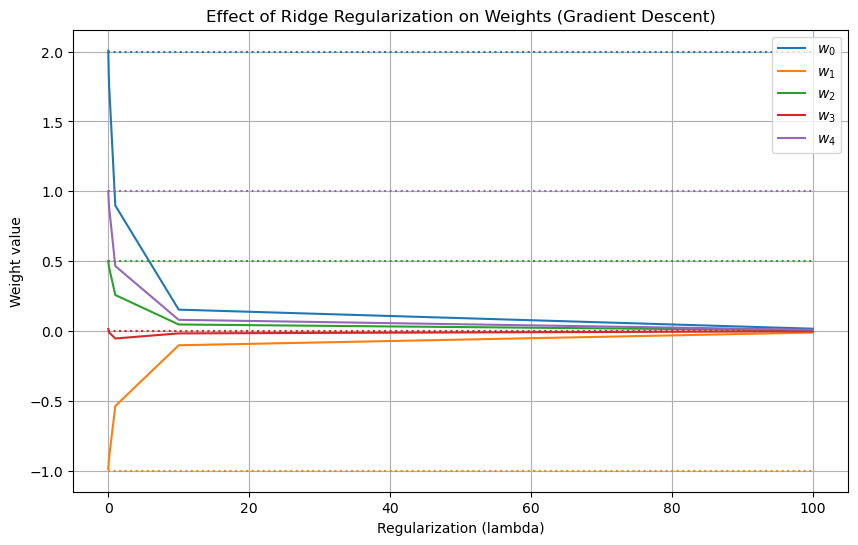

In [2]:
import numpy as np
import matplotlib.pyplot as plt


#  Generate synthetic data
np.random.seed(42)
N = 100
D = 5
X = np.random.randn(N, D)
w_true = np.array([2, -1, 0.5, 0, 1])
y = X @ w_true + 0.1 * np.random.randn(N)

# Regularization sweep
lambdas = [0, 0.01, 0.1, 1, 10, 100]
weights_over_lambda = []

for lam in lambdas:
    model = RidgeGradientDescent(eta=0.01, lambda_=lam, add_bias=False)
    model.fit(X, y)
    print('\n')
    weights_over_lambda.append(model.weights)

weights_over_lambda = np.array(weights_over_lambda)

# 3. Plot
plt.figure(figsize=(10, 6))
for i in range(weights_over_lambda.shape[1]):
    plt.plot(lambdas, weights_over_lambda[:, i], label=f"$w_{i}$")
    plt.hlines(w_true[i], xmin=lambdas[0], xmax=lambdas[-1], linestyles='dotted', colors='C'+str(i))

plt.xlabel("Regularization (lambda)")
plt.ylabel("Weight value")
plt.title("Effect of Ridge Regularization on Weights (Gradient Descent)")
plt.xscale("linear")
plt.legend()
plt.grid(True)
plt.show()

---

## 4. Visualization

- Plot $w(\lambda)$ as a function of $\lambda$  

Plot shows how increasing regularization shrinks weights towards zero.

---

## 5. Interpretation

- $\lambda = 0$ → ordinary least squares (fits data closely)  
- $\lambda \uparrow$ → weights shrink, preventing overfitting  
- Features with small effect are shrunk faster  
- Bias term is **not regularized**

---